In [ ]:
# Google Colab only (does nothing elsewhere): fetch the bundle next to this notebook and install pPXF.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")     # one core on Colab / Binder
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ppxf", "fitsio", "ipywidgets"], check=True)
    if not os.path.exists("interbars_students"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/EdoBorsato/INTERBARS_classes"], check=True)
    os.chdir("interbars_students/reference"); print("Colab: working in", os.getcwd())

# 3. Your galaxy on the BPT diagram

With pPXF line fluxes for every nucleus of the sample (`results/tables/ppxf_lines.csv`: 54 spectra, main
galaxies and companions, DESI and SDSS) each of you takes **one system** — a galaxy, a pair, or a few — and
answers for it: *stars or black hole in the nucleus?* and *does my galaxy look like a typical interacting
galaxy, like a typical barred galaxy, or like neither?*

Tools: the BPT diagram (Baldwin, Phillips & Terlevich 1981) with the **Kauffmann et al. (2003)** and
**Kewley et al. (2001)** demarcations (star-forming / composite / AGN) and the **Schawinski et al. (2007)**
Seyfert–LINER line; and two large SDSS comparison populations with the same lines measured by the MPA-JHU
group (Brinchmann et al. 2004): **spectroscopic pairs** (a companion within 30 kpc and 500 km/s) and
**barred galaxies** (visual bars of Nair & Abraham 2010). Their distributions are drawn as contours
enclosing 20, 50 and 80 % of each population.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):    # one BLAS thread: on Binder / Colab the pod has
    os.environ.setdefault(_v, "1")                                          # one core and multi-threaded BLAS is 30x slower
import os, io, sys
from pathlib import Path
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "dataset").is_dir())   # the course folder
sys.path.insert(0, str(ROOT / "scripts"))
import plot_bpt_ppxf as PB                # the project's BPT plotting (one point per galaxy, pairs joined)
import bpt_comparison as BC               # comparison samples and the stage-vs-population statistics
plt.rcParams.update({"figure.dpi": 110})
STAGE = {0: "pre-interaction", 1: "merger", 2: "post-merger"}
print("repo:", ROOT)

repo: /home/eborsato/PyAutoThings/workspace/interbars


## 3.1 Your system

`MY_SYSTEMS` comes from notebook 1 (`reference/my_systems.json`). Every spectrum of those systems is
kept: the main galaxy, its companion if there is one, and both the DESI and the SDSS spectrum where both
exist (different fibres: 1.5″ and 3″).

In [2]:
import json
MY_SYSTEMS = json.loads((ROOT / "reference/my_systems.json").read_text()) if (ROOT / "reference/my_systems.json").exists() else ["IC3147B"]   # set in notebook 1
t = pd.read_csv(ROOT / "results/tables/ppxf_lines.csv")
tg = pd.read_csv(ROOT / "dataset/catalogs/interbars_targets.csv").set_index("system")
sz = pd.read_csv(ROOT / "dataset/catalogs/interbars_specz.csv").set_index("system")
t["stage"] = t.system.map(tg.class_VC).map(STAGE).fillna("unclassified")
mine = t[t.system.isin(MY_SYSTEMS)].copy()
print(f"available systems: {sorted(t.system.unique())}\n")
for s_ in MY_SYSTEMS:
    r = tg.loc[s_]; print(f"{s_}: z = {r.z_hand:.4f}, VC class {r.class_VC:.0f} ({STAGE.get(r.class_VC, '?')}), EB class {r.class_EB:.0f}; companion: {r.comp_name if isinstance(r.comp_name, str) else 'none'}"
          + (f" at {sz.loc[s_, 'comp_sep_kpc']:.0f} kpc, dv {sz.loc[s_, 'dv_comp_kms']:+.0f} km/s" if isinstance(r.comp_name, str) else "") + (f"\n   note: {r.note}" if isinstance(r.note, str) else ""))
cols = ["label", "role", "source", "z_fit", "ha_flux", "ha_err", "hb_flux", "hb_err", "oiii_flux", "oiii_err", "nii_flux", "nii_err", "log_nii_ha", "log_nii_ha_err", "log_oiii_hb", "log_oiii_hb_err", "min_snr_bpt", "bpt_class", "broad_adopted"]
print(); print(mine[cols].round(3).to_string(index=False))

available systems: ['2MASXJ08232861+0924041', '2MASXJ09551395+1417576', '2MASXJ11422226+0845548', '2dFGRSTGN313Z174', '2dFGRSTGN321Z156', 'BKD2008WR561', 'IC2810', 'IC2867', 'IC3147B', 'IC3378', 'IC775', 'LEDA1050044', 'LEDA11650', 'LEDA1232789', 'LEDA1348189', 'LEDA1436844', 'LEDA176192', 'LEDA181851', 'LEDA3091410', 'MCG-01-09-041', 'Mrk1302', 'NGC2864', 'NVSSJ084256+133826', 'NVSSJ100720+040434', 'UGC6142', 'Z44-80', 'Z63-63', 'Z64-106']

IC3147B: z = 0.0256, VC class 1 (merger), EB class 1; companion: IC3147 at 12 kpc, dv +111 km/s
   note: reduction position 15" from SIMBAD; LS reduction cutout centre off the galaxy (pair cutout centred between members?)

            label role source  z_fit  ha_flux  ha_err  hb_flux  hb_err  oiii_flux  oiii_err  nii_flux  nii_err  log_nii_ha  log_nii_ha_err  log_oiii_hb  log_oiii_hb_err  min_snr_bpt bpt_class  broad_adopted
          IC3147B main   DESI  0.026  725.730   3.772  180.370   3.391     55.050     3.097    401.72    3.146      -0.257  

## 3.2 Your nuclei on the BPT, over the pairs and the barred galaxies

Large symbols with labels: your spectra (circle = DESI, triangle = SDSS; a line joins the two nuclei of a
pair; a ring marks a detected broad Hα). Small grey points: the rest of the sample. Blue contours: SDSS
pairs; purple dashed: SDSS barred galaxies.

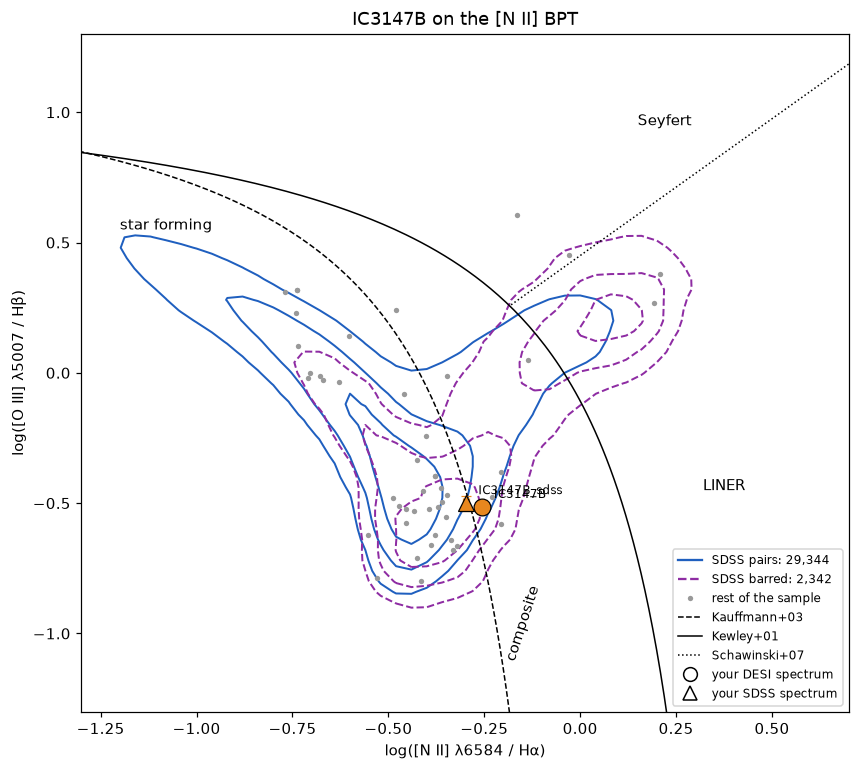

In [3]:
sdss = BC.ratios(BC.load_sdss())
sdss["pair"] = BC.sdss_pairs(sdss, 30.0, 500.0); sdss["in_nair"], sdss["bar"], sdss["napair"], sdss["inter"] = BC.nair_match(sdss)
pops = {"pairs": sdss[sdss.pair], "barred": sdss[sdss.bar]}
grids = {k: BC.density_grid(v.n2.values, v.o3.values) for k, v in pops.items()}
STYLE = {"pairs": ("#1f5fbf", "solid"), "barred": ("#8e2ca3", "dashed")}
ok = t.min_snr_bpt >= 3

def bpt_with_contours(ax, panel="n2"):
    xcol = "log_nii_ha" if panel == "n2" else "log_sii_ha"
    for k, P in pops.items():
        xc, yc, H, lev = BC.contour_levels(P[panel].values, P.o3.values, (-1.3, 0.7) if panel == "n2" else (-1.2, 0.6), (-1.3, 1.3))
        ax.contour(xc, yc, H, levels=lev, colors=[STYLE[k][0]], linewidths=1.3, linestyles=STYLE[k][1]); ax.plot([], [], color=STYLE[k][0], ls=STYLE[k][1], label=f"SDSS {k}: {len(P):,}")
    rest = t[ok & ~t.system.isin(MY_SYSTEMS)]; ax.plot(rest[xcol], rest.log_oiii_hb, "o", ms=3.5, color="0.6", mec="none", label="rest of the sample")
    PB.demarcations(ax, panel)

fig, ax = plt.subplots(figsize=(9, 8)); bpt_with_contours(ax, "n2")
m = mine[mine.min_snr_bpt >= 3]
for s_, g in m.groupby("system"):
    for src in ("DESI", "SDSS"):
        gg = g[g.source == src]
        if len(gg) == 2:                                     # main + companion of this system, same survey: join them
            ax.plot(gg.log_nii_ha, gg.log_oiii_hb, "-", color=PB.COL.get(gg.stage.iloc[0], "k") if False else "0.3", lw=1.2, zorder=4)
for r in m.itertuples():
    col = {"pre-interaction": "#c8102e", "merger": "#e8871e", "post-merger": "#2a9d3f"}.get(r.stage, "0.4")
    ax.errorbar(r.log_nii_ha, r.log_oiii_hb, xerr=r.log_nii_ha_err, yerr=r.log_oiii_hb_err, fmt="o" if r.source == "DESI" else "^", ms=11, mfc=col, mec="k", mew=0.8, ecolor=col, capsize=3, zorder=6)
    if r.broad_adopted: ax.plot(r.log_nii_ha, r.log_oiii_hb, "o", ms=19, mfc="none", mec="k", mew=1.2, zorder=7)
    ax.annotate(f"{r.label}", (r.log_nii_ha, r.log_oiii_hb), xytext=(8, 6), textcoords="offset points", fontsize=8, zorder=8)
ax.plot([], [], "o", ms=9, mfc="w", mec="k", label="your DESI spectrum"); ax.plot([], [], "^", ms=9, mfc="w", mec="k", label="your SDSS spectrum")
ax.legend(fontsize=8, loc="lower right"); ax.set_title(f"{', '.join(MY_SYSTEMS)} on the [N II] BPT"); plt.show()

## 3.3 Which population does your nucleus agree with?

For each of your spectra: the BPT class; the **contour level** at which the point sits in each population
(0.3 means "inside the contour that encloses 30 % of that population", i.e. in its dense core; 0.95 means
in its outskirts); the **density ratio** pairs / barred at the point (how many times more likely a pair
than a barred galaxy is to have these line ratios); and a verdict. A nucleus can be typical of both — the
two populations overlap on the star-forming sequence — so read the ratio, not only the verdict.

In [4]:
def contour_level_at(grid, x, y):
    # fraction of the population enclosed by the contour passing through (x, y)
    xe, ye, H = grid; dens = BC.eval_density(grid, np.atleast_1d(x), np.atleast_1d(y))[0]
    srt = np.sort(H.ravel())[::-1]; return float(np.cumsum(srt)[np.searchsorted(-srt, -dens)])

rows = []
for r in m.itertuples():
    lv = {k: contour_level_at(grids[k], r.log_nii_ha, r.log_oiii_hb) for k in pops}
    dens = {k: BC.eval_density(grids[k], np.atleast_1d(r.log_nii_ha), np.atleast_1d(r.log_oiii_hb))[0] for k in pops}
    ratio = dens["pairs"] / max(dens["barred"], 1e-12)
    verdict = ("typical of both" if lv["pairs"] < 0.8 and lv["barred"] < 0.8 else "typical of pairs only" if lv["pairs"] < 0.8 else "typical of barred galaxies only" if lv["barred"] < 0.8 else "outskirts of both")
    verdict += f"; {'pairs' if ratio > 2 else 'barred' if ratio < 0.5 else 'either'} favoured ({ratio:.1f}x)"
    rows.append(dict(label=r.Index if False else r.label, source=r.source, bpt_class=r.bpt_class, level_pairs=lv["pairs"], level_barred=lv["barred"], pairs_over_barred=ratio, verdict=verdict))
verdicts = pd.DataFrame(rows); pd.set_option("display.width", 220); print(verdicts.round(2).to_string(index=False))

       label source bpt_class  level_pairs  level_barred  pairs_over_barred                                 verdict
     IC3147B   DESI composite         0.64          0.20               0.39 typical of both; barred favoured (0.4x)
IC3147B_sdss   SDSS        SF         0.48          0.08               0.54 typical of both; either favoured (0.5x)


## 3.4 Your galaxy's numbers

Everything pPXF measured, in one table per spectrum: line fluxes with errors, the Balmer decrement and the
gas reddening it implies ($E(B-V) = 1.97\,\log_{10}[({\rm H}\alpha/{\rm H}\beta)/2.86]$, Calzetti law),
the dust-corrected Hα flux, the stellar velocity dispersion and light-weighted age, the gas kinematics, and
the broad-line test. The [S II] and [O I] ratios give the two other diagnostic diagrams (Kewley et al. 2006);
compute their classes as an exercise.

In [5]:
def calzetti_k(w_A):
    w = w_A / 1e4
    return np.where(w < 0.63, 2.659 * (-2.156 + 1.509 / w - 0.198 / w**2 + 0.011 / w**3) + 4.05, 2.659 * (-1.857 + 1.040 / w) + 4.05)
mine["ebv_gas"] = (1.97 * np.log10(mine.balmer_dec / 2.86)).clip(lower=0)
mine["ha_flux_dustcorr"] = mine.ha_flux * 10 ** (0.4 * mine.ebv_gas * calzetti_k(np.array([6564.6]))[0])
show = ["label", "source", "z_fit", "hb_flux", "hb_err", "oiii_flux", "oiii_err", "ha_flux", "ha_err", "nii_flux", "nii_err", "sii6716_flux", "sii6731_flux", "oi_flux",
        "balmer_dec", "ebv_gas", "ha_flux_dustcorr", "log_nii_ha", "log_oiii_hb", "log_sii_ha", "log_oi_ha", "bpt_class",
        "sigma_star", "age_lw_gyr", "metal_lw", "sigma_balmer", "sigma_forbidden", "broad_adopted", "dchi2_broad", "snr_broad_halpha", "chi2"]
print(mine[show].set_index("label").T.round(3).to_string())

label                 IC3147B IC3147B_sdss IC3147B_comp_sdss
source                   DESI         SDSS              SDSS
z_fit                 0.02567     0.025643          0.025567
hb_flux                180.37       263.96            29.199
hb_err                 3.3907        6.101             12.37
oiii_flux               55.05       83.297             66.36
oiii_err               3.0972       5.0319            10.897
ha_flux                725.73       1119.4            98.683
ha_err                 3.7716       10.712            13.421
nii_flux               401.72       564.42            105.28
nii_err                3.1456       7.6227            12.076
sii6716_flux           162.37       224.17            41.768
sii6731_flux           123.21       171.85            55.723
oi_flux                40.602       45.761           0.17833
balmer_dec             4.0236       4.2407            3.3796
ebv_gas               0.29205     0.337011          0.142824
ha_flux_dustcorr  1774.9

## 3.5 The whole sample, for context

The same diagram with every nucleus of the sample, one spectrum per galaxy (DESI where both exist),
coloured by the VC interaction class, both nuclei of a pair joined; and the per-class statistics against
the two populations (fraction of nuclei inside the 80 % contour, mean log-density, and a two-dimensional
energy-distance permutation test). Where does your system sit in that picture?

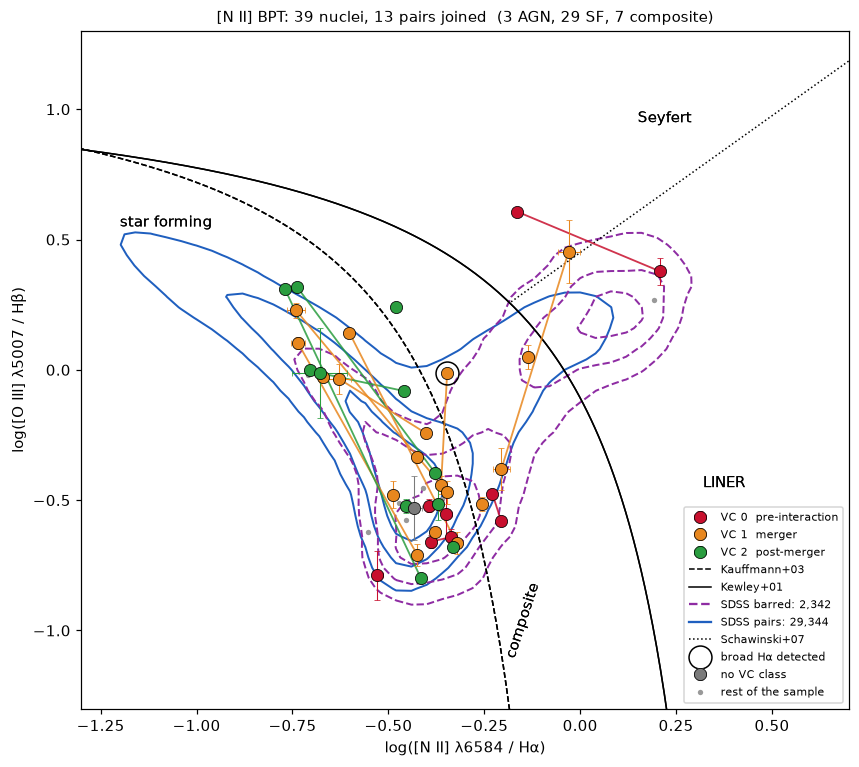

                stage  n population  frac_in80  mean_logdens  p_energy  nonsf_frac_sample  nonsf_frac_pop
VC 0  pre-interaction  9      pairs      0.556        -3.006     0.010              0.444           0.246
VC 0  pre-interaction  9     barred      0.889        -2.674     0.040              0.444           0.578
VC 0  pre-interaction  9        all      0.556        -2.973     0.000              0.444           0.299
         VC 1  merger 18      pairs      0.944        -2.700     0.315              0.278           0.246
         VC 1  merger 18     barred      0.778        -2.803     0.035              0.278           0.578
         VC 1  merger 18        all      0.944        -2.691     0.690              0.278           0.299
    VC 2  post-merger 11      pairs      0.818        -2.776     0.670              0.091           0.246
    VC 2  post-merger 11     barred      0.636        -3.072     0.000              0.091           0.578
    VC 2  post-merger 11        all      0.727

In [6]:
pts, pairs = PB.load_sample()
fig, ax = plt.subplots(figsize=(9, 8)); bpt_with_contours(ax, "n2"); ax.lines[-1].remove()      # contours + demarcations, without the grey sample points
PB.draw_panel(ax, pts, pairs, "n2"); PB.sample_legend(ax, loc="lower right"); plt.show()
stats = BC.stage_consistency(pts, {**pops, "all": sdss}, nboot=200, nperm=200, seed=1)
print(stats[["stage", "n", "population", "frac_in80", "mean_logdens", "p_energy", "nonsf_frac_sample", "nonsf_frac_pop"]].round(3).to_string(index=False))

## Exercises

1. Classify your nuclei on the [S II] and [O I] diagrams (Kewley et al. 2006 curves are in
   `scripts/plot_bpt_ppxf.py`). Do the three diagrams agree?
2. If your galaxy has both a DESI and an SDSS spectrum: the fibres are 1.5″ and 3″. Which fluxes change,
   which ratios? What does that say about where the line emission comes from?
3. Move your point by ±1σ along both axes. Does the class change? Does the verdict of 3.3?
4. Look at your galaxy's image (notebook 1) and the classification note: is the VC class consistent with
   what you see? Would you call the companion a companion?
5. Compute EW(Hα) from notebook 2 (gas flux / stellar continuum under the line) and place your nucleus on
   the WHAN diagram (Cid Fernandes et al. 2011: EW < 3 Å = "retired"). Does it change your answer?